# 01 — Inspect dataset

This notebook checks the raw EEG files before feature extraction.

Main goals:

1. Load the manifest created in the previous step.
2. Inspect basic metadata: sampling frequency, duration, channels, annotations.
3. Confirm that the `Status` channel is excluded from EEG analyses.
4. Inspect channel layouts across all recordings.
5. Create report-ready example plots using manual `matplotlib` plotting rather than MNE's interactive `.plot()` functions.
6. Decide preprocessing settings for the next notebook.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne

# Optional: suppress very verbose MNE output.
mne.set_log_level("WARNING")

# Change this only if the project folder moves.
PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")

MANIFEST_FILE = PROJECT_ROOT / "data_processed" / "manifest.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

manifest = pd.read_csv(MANIFEST_FILE)

print("Manifest shape:", manifest.shape)
manifest.head()


Manifest shape: (1216, 11)


,recording_id,participant_id,pair_id,session,acquisition,condition,age,sex,handedness,eeg_path,complete_pair
0,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,1,pre,EC,60,F,right,data/ds005385/sub-001/ses-1/eeg/sub-001_ses-1_...,True
1,sub-001_ses-1_pre_EO,sub-001,sub-001_ses-1_pre,1,pre,EO,60,F,right,data/ds005385/sub-001/ses-1/eeg/sub-001_ses-1_...,True
2,sub-002_ses-1_pre_EC,sub-002,sub-002_ses-1_pre,1,pre,EC,67,M,right,data/ds005385/sub-002/ses-1/eeg/sub-002_ses-1_...,True
3,sub-002_ses-1_pre_EO,sub-002,sub-002_ses-1_pre,1,pre,EO,67,M,right,data/ds005385/sub-002/ses-1/eeg/sub-002_ses-1_...,True
4,sub-003_ses-1_pre_EC,sub-003,sub-003_ses-1_pre,1,pre,EC,44,F,right,data/ds005385/sub-003/ses-1/eeg/sub-003_ses-1_...,True


## 1. Select a small inspection sample

We inspect a few participants across the dataset. This is only for visual and technical checks.


In [2]:
all_subjects = sorted(manifest["participant_id"].unique())

sample_subjects = [
    all_subjects[0],
    all_subjects[len(all_subjects)//4],
    all_subjects[len(all_subjects)//2],
    all_subjects[3*len(all_subjects)//4],
    all_subjects[-1],
]

sample_manifest = manifest[
    manifest["participant_id"].isin(sample_subjects)
].copy()

print("Sample subjects:", sample_subjects)
sample_manifest


Sample subjects: ['sub-001', 'sub-153', 'sub-305', 'sub-457', 'sub-608']


,recording_id,participant_id,pair_id,session,acquisition,condition,age,sex,handedness,eeg_path,complete_pair
0,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,1,pre,EC,60,F,right,data/ds005385/sub-001/ses-1/eeg/sub-001_ses-1_...,True
1,sub-001_ses-1_pre_EO,sub-001,sub-001_ses-1_pre,1,pre,EO,60,F,right,data/ds005385/sub-001/ses-1/eeg/sub-001_ses-1_...,True
304,sub-153_ses-1_pre_EC,sub-153,sub-153_ses-1_pre,1,pre,EC,29,F,right,data/ds005385/sub-153/ses-1/eeg/sub-153_ses-1_...,True
305,sub-153_ses-1_pre_EO,sub-153,sub-153_ses-1_pre,1,pre,EO,29,F,right,data/ds005385/sub-153/ses-1/eeg/sub-153_ses-1_...,True
608,sub-305_ses-1_pre_EC,sub-305,sub-305_ses-1_pre,1,pre,EC,42,M,right,data/ds005385/sub-305/ses-1/eeg/sub-305_ses-1_...,True
609,sub-305_ses-1_pre_EO,sub-305,sub-305_ses-1_pre,1,pre,EO,42,M,right,data/ds005385/sub-305/ses-1/eeg/sub-305_ses-1_...,True
912,sub-457_ses-1_pre_EC,sub-457,sub-457_ses-1_pre,1,pre,EC,42,M,right,data/ds005385/sub-457/ses-1/eeg/sub-457_ses-1_...,True
913,sub-457_ses-1_pre_EO,sub-457,sub-457_ses-1_pre,1,pre,EO,42,M,right,data/ds005385/sub-457/ses-1/eeg/sub-457_ses-1_...,True
1214,sub-608_ses-1_pre_EC,sub-608,sub-608_ses-1_pre,1,pre,EC,25,F,right,data/ds005385/sub-608/ses-1/eeg/sub-608_ses-1_...,True
1215,sub-608_ses-1_pre_EO,sub-608,sub-608_ses-1_pre,1,pre,EO,25,F,right,data/ds005385/sub-608/ses-1/eeg/sub-608_ses-1_...,True


## 2. Load one recording and inspect metadata

In [3]:
row = sample_manifest.iloc[0]
eeg_file = PROJECT_ROOT / row["eeg_path"]

raw = mne.io.read_raw_edf(eeg_file, preload=False, verbose=False)

print("Recording:", row["recording_id"])
print("File:", eeg_file)
print("Sampling frequency:", raw.info["sfreq"])
print("Duration seconds:", raw.times[-1])
print("Number of channels:", len(raw.ch_names))
print("Channel names:")
print(raw.ch_names)

print("\nChannel types:")
print(pd.Series(raw.get_channel_types()).value_counts())


Recording: sub-001_ses-1_pre_EC
File: C:\Users\maria\Desktop\EEG-special-course\data\ds005385\sub-001\ses-1\eeg\sub-001_ses-1_task-EyesClosed_acq-pre_eeg.edf
Sampling frequency: 1000.0
Duration seconds: 183.999
Number of channels: 65
Channel names:
['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FT9', 'FT7', 'FC3', 'FC4', 'FT8', 'FT10', 'C5', 'C1', 'C2', 'C6', 'TP7', 'CP3', 'CPz', 'CP4', 'TP8', 'P5', 'P1', 'P2', 'P6', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'Status']

Channel types:
eeg     64
stim     1
Name: count, dtype: int64


## 3. Inspect metadata for the sample recordings

In [4]:
inspection_rows = []

for _, row in sample_manifest.iterrows():
    eeg_file = PROJECT_ROOT / row["eeg_path"]
    raw = mne.io.read_raw_edf(eeg_file, preload=False, verbose=False)

    inspection_rows.append({
        "recording_id": row["recording_id"],
        "participant_id": row["participant_id"],
        "condition": row["condition"],
        "sfreq": raw.info["sfreq"],
        "duration_sec": raw.times[-1],
        "n_channels_total": len(raw.ch_names),
        "n_eeg_channels": sum(ch_type == "eeg" for ch_type in raw.get_channel_types()),
        "n_annotations": len(raw.annotations),
    })

inspection_df = pd.DataFrame(inspection_rows)
inspection_df


,recording_id,participant_id,condition,sfreq,duration_sec,n_channels_total,n_eeg_channels,n_annotations
0,sub-001_ses-1_pre_EC,sub-001,EC,1000.0,183.999,65,64,0
1,sub-001_ses-1_pre_EO,sub-001,EO,1000.0,183.999,65,64,0
2,sub-153_ses-1_pre_EC,sub-153,EC,1000.0,182.999,65,64,0
3,sub-153_ses-1_pre_EO,sub-153,EO,1000.0,182.999,65,64,0
4,sub-305_ses-1_pre_EC,sub-305,EC,1000.0,182.999,65,64,0
5,sub-305_ses-1_pre_EO,sub-305,EO,1000.0,183.999,65,64,0
6,sub-457_ses-1_pre_EC,sub-457,EC,1000.0,183.999,65,64,0
7,sub-457_ses-1_pre_EO,sub-457,EO,1000.0,185.999,65,64,0
8,sub-608_ses-1_pre_EC,sub-608,EC,1000.0,182.999,65,64,0
9,sub-608_ses-1_pre_EO,sub-608,EO,1000.0,198.999,65,64,0


## 4. Check channel layouts across all recordings

This checks whether all files have the same channels and whether the posterior channels needed for the report are present.


In [5]:
channel_rows = []

for _, row in manifest.iterrows():
    eeg_file = PROJECT_ROOT / row["eeg_path"]
    raw = mne.io.read_raw_edf(eeg_file, preload=False, verbose=False)

    channel_rows.append({
        "recording_id": row["recording_id"],
        "participant_id": row["participant_id"],
        "condition": row["condition"],
        "n_channels_total": len(raw.ch_names),
        "channels": tuple(raw.ch_names),
        "eeg_channels": tuple(
            ch for ch, ch_type in zip(raw.ch_names, raw.get_channel_types())
            if ch_type == "eeg"
        ),
    })

channel_df = pd.DataFrame(channel_rows)

print("Unique total channel-count values:")
print(channel_df["n_channels_total"].value_counts())

print("\nNumber of unique full channel layouts:")
print(channel_df["channels"].nunique())

print("\nNumber of unique EEG-only channel layouts:")
print(channel_df["eeg_channels"].nunique())


Unique total channel-count values:
n_channels_total
65    1216
Name: count, dtype: int64

Number of unique full channel layouts:
2

Number of unique EEG-only channel layouts:
2


In [6]:
unique_layouts = (
    channel_df[["channels"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

for i, layout in enumerate(unique_layouts["channels"]):
    print(f"\nFull layout {i + 1}")
    print(layout)



Full layout 1
('Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FT9', 'FT7', 'FC3', 'FC4', 'FT8', 'FT10', 'C5', 'C1', 'C2', 'C6', 'TP7', 'CP3', 'CPz', 'CP4', 'TP8', 'P5', 'P1', 'P2', 'P6', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'Status')

Full layout 2
('Fp2', 'Fp1', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FT9', 'FT7', 'FC3', 'FC4', 'FT8', 'FT10', 'C5', 'C1', 'C2', 'C6', 'TP7', 'CP3', 'CPz', 'CP4', 'TP8', 'P5', 'P1', 'P2', 'P6', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'Status')


In [7]:
layouts_by_recording = (
    channel_df
    .assign(layout_id=channel_df["channels"].factorize()[0] + 1)
    .groupby("layout_id")
    .agg(
        n_recordings=("recording_id", "size"),
        example_recording=("recording_id", "first"),
    )
    .reset_index()
)

layouts_by_recording


,layout_id,n_recordings,example_recording
0,1,1214,sub-001_ses-1_pre_EC
1,2,2,sub-075_ses-1_pre_EC


In [8]:
# Define channel sets based on the first EEG-only layout.
all_eeg_channels = list(channel_df.iloc[0]["eeg_channels"])

OZ_CHANNELS = [ch for ch in ["Oz"] if ch in all_eeg_channels]

OCCIPITAL_CHANNELS = [
    ch for ch in ["O1", "Oz", "O2"]
    if ch in all_eeg_channels
]

POSTERIOR_CHANNELS = [
    ch for ch in all_eeg_channels
    if ch.startswith(("P", "PO", "O"))
]

print("Oz:", OZ_CHANNELS)
print("Occipital:", OCCIPITAL_CHANNELS)
print("Posterior:", POSTERIOR_CHANNELS)
print("N posterior:", len(POSTERIOR_CHANNELS))

# Verify posterior channels exist in every EEG-only layout.
missing_by_layout = []

for layout_id, eeg_channels in enumerate(channel_df["eeg_channels"].drop_duplicates(), start=1):
    missing = sorted(set(POSTERIOR_CHANNELS) - set(eeg_channels))
    missing_by_layout.append({
        "layout_id": layout_id,
        "n_missing_posterior_channels": len(missing),
        "missing_posterior_channels": ", ".join(missing),
    })

pd.DataFrame(missing_by_layout)


Oz: ['Oz']
Occipital: ['O1', 'Oz', 'O2']
Posterior: ['P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10', 'P5', 'P1', 'P2', 'P6', 'PO7', 'PO3', 'POz', 'PO4', 'PO8']
N posterior: 19


,layout_id,n_missing_posterior_channels,missing_posterior_channels
0,1,0,
1,2,0,


## 5. Helper functions for preprocessing and PSD plotting


In [9]:
def load_raw_eeg(row, preload=True):
    """Load one EDF recording and keep EEG channels only."""
    eeg_file = PROJECT_ROOT / row["eeg_path"]
    raw = mne.io.read_raw_edf(eeg_file, preload=preload, verbose=False)
    raw.pick("eeg")  # removes Status/stim channel
    return raw


def preprocess_raw(raw):
    """Apply the candidate preprocessing used for inspection."""
    raw_filt = raw.copy().load_data()

    # Remove line noise first, then band-pass.
    raw_filt.notch_filter(freqs=50, verbose=False)
    raw_filt.filter(
        l_freq=1,
        h_freq=40,
        method="fir",
        phase="zero",
        verbose=False,
    )
    return raw_filt


def compute_mean_psd(raw, picks=None, fmin=0.5, fmax=60):
    """Return frequencies and mean PSD across selected channels."""
    if picks is None:
        picks = "eeg"

    psd = raw.compute_psd(
        picks=picks,
        fmin=fmin,
        fmax=fmax,
        method="welch",
        verbose=False,
    )

    freqs = psd.freqs
    power = psd.get_data().mean(axis=0)

    return freqs, power


def power_to_db(power):
    """Convert power to dB safely."""
    return 10 * np.log10(np.maximum(power, np.finfo(float).tiny))


## 6. Plot a raw EEG segment

Loaded: sub-001_ses-1_pre_EC
EEG channels: 64
Duration: 183.999
Sampling frequency: 1000.0


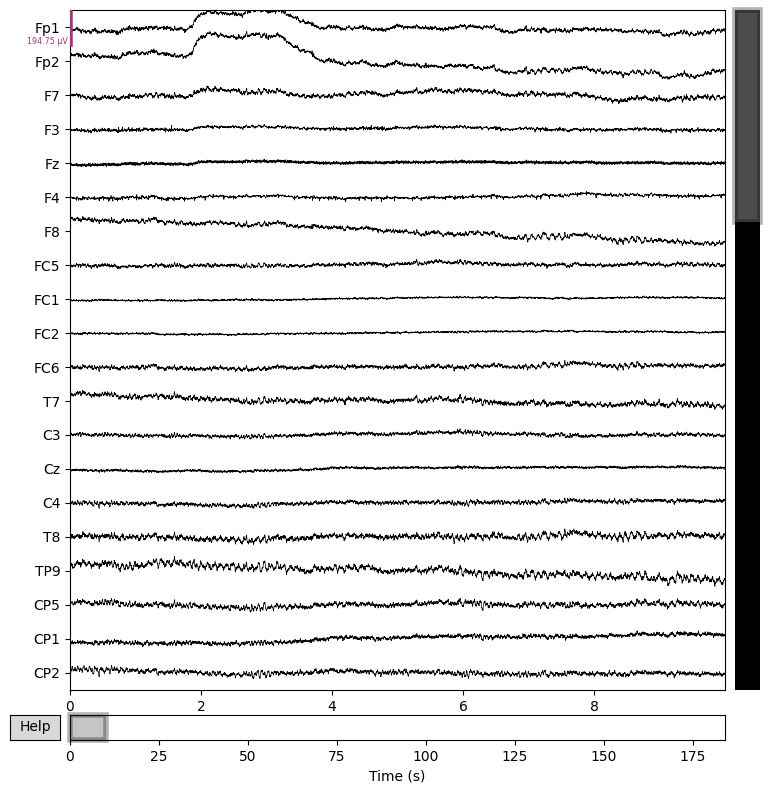

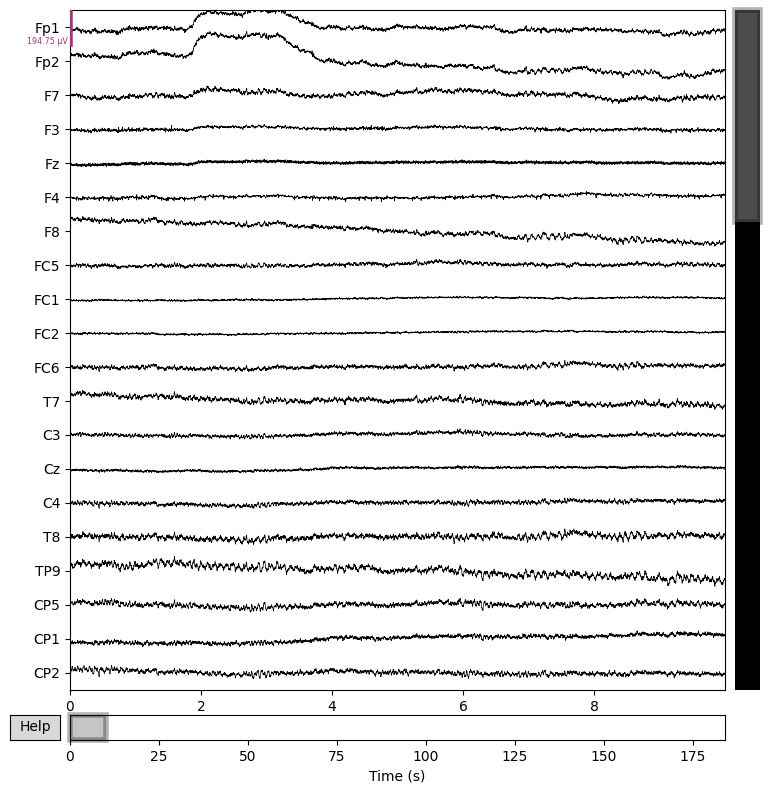

In [10]:
row = sample_manifest[
    (sample_manifest["participant_id"] == sample_subjects[0]) &
    (sample_manifest["condition"] == "EC")
].iloc[0]

raw = load_raw_eeg(row, preload=True)

print("Loaded:", row["recording_id"])
print("EEG channels:", len(raw.ch_names))
print("Duration:", raw.times[-1])
print("Sampling frequency:", raw.info["sfreq"])

# This interactive plot may display differently depending on your notebook backend.
raw.plot(
    start=0,
    duration=10,
    n_channels=20,
    scalings="auto",
    title=f"Raw EEG example: {row['recording_id']}",
    show=True,
)


## 7. Raw versus filtered PSD

This plot should always render because it is created directly with `matplotlib`.


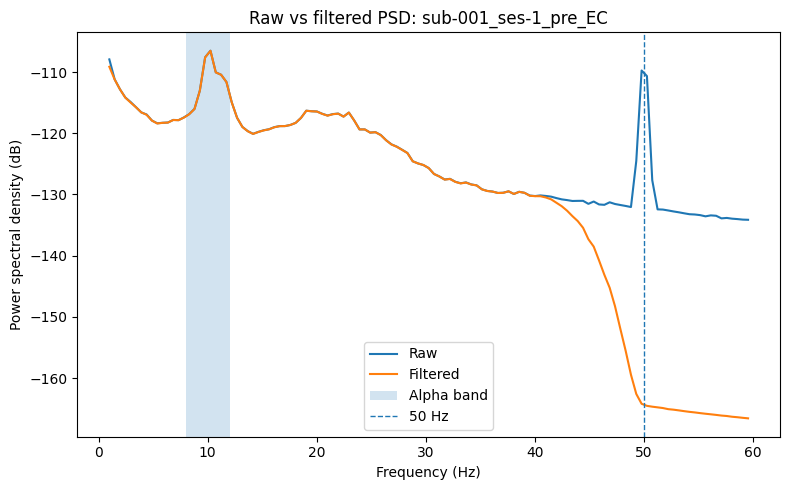

In [11]:
raw = load_raw_eeg(row, preload=True)
raw_filt = preprocess_raw(raw)

freqs_raw, power_raw = compute_mean_psd(raw, fmin=0.5, fmax=60)
freqs_filt, power_filt = compute_mean_psd(raw_filt, fmin=0.5, fmax=60)

plt.figure(figsize=(8, 5))
plt.plot(freqs_raw, power_to_db(power_raw), label="Raw")
plt.plot(freqs_filt, power_to_db(power_filt), label="Filtered")
plt.axvspan(8, 12, alpha=0.2, label="Alpha band")
plt.axvline(50, linestyle="--", linewidth=1, label="50 Hz")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density (dB)")
plt.title(f"Raw vs filtered PSD: {row['recording_id']}")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "raw_vs_filtered_psd_example.png", dpi=300)
plt.show()


## 8. EO versus EC posterior PSD for one participant

This is the most report-relevant inspection plot. It checks whether posterior alpha power is higher in Eyes Closed than Eyes Open for an example participant.


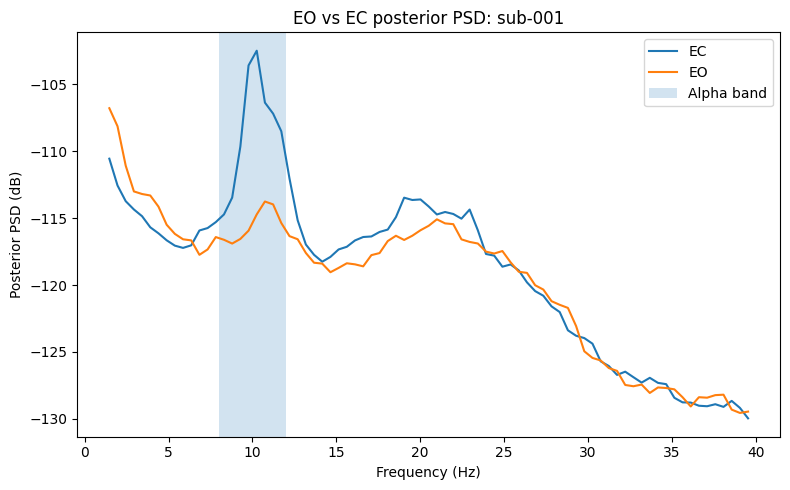

In [12]:
participant = sample_subjects[0]

participant_rows = sample_manifest[
    sample_manifest["participant_id"].eq(participant)
].copy()

plt.figure(figsize=(8, 5))

for _, row in participant_rows.iterrows():
    raw = load_raw_eeg(row, preload=True)
    raw_filt = preprocess_raw(raw)

    existing_posterior = [
        ch for ch in POSTERIOR_CHANNELS
        if ch in raw_filt.ch_names
    ]

    freqs, power = compute_mean_psd(
        raw_filt,
        picks=existing_posterior,
        fmin=1,
        fmax=40,
    )

    plt.plot(freqs, power_to_db(power), label=row["condition"])

plt.axvspan(8, 12, alpha=0.2, label="Alpha band")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Posterior PSD (dB)")
plt.title(f"EO vs EC posterior PSD: {participant}")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "example_eo_ec_posterior_psd.png", dpi=300)
plt.show()


## 9. EO versus EC posterior PSD for several participants

This gives a quick visual check that the expected EO–EC alpha difference is not limited to one example.


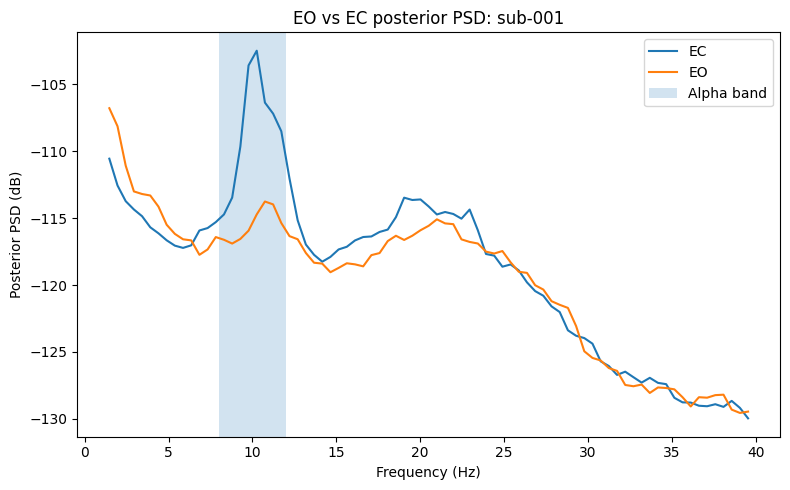

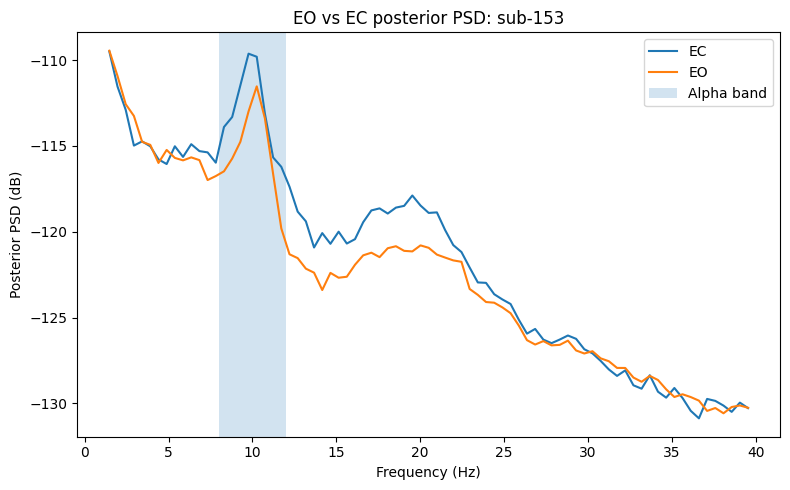

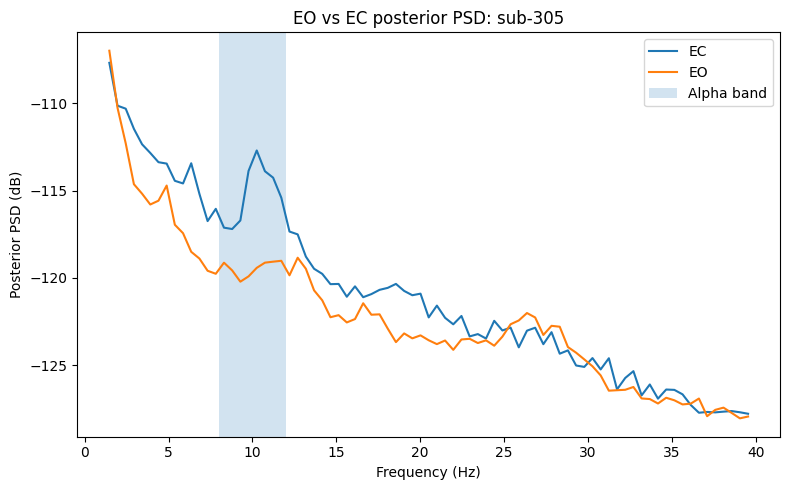

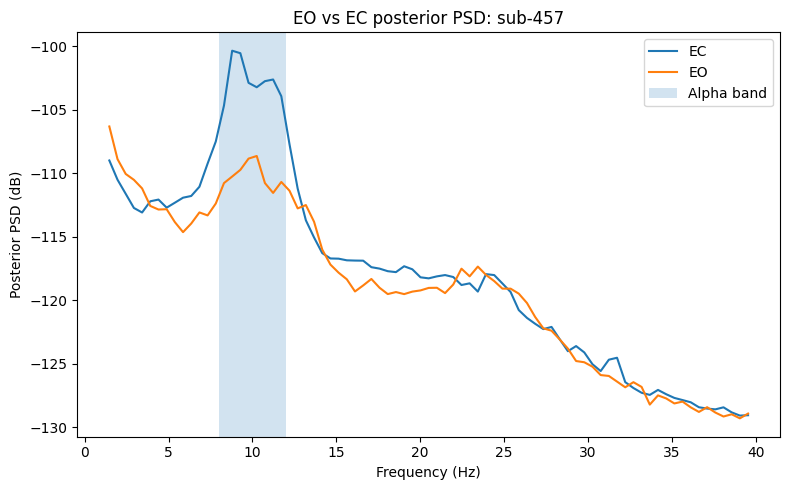

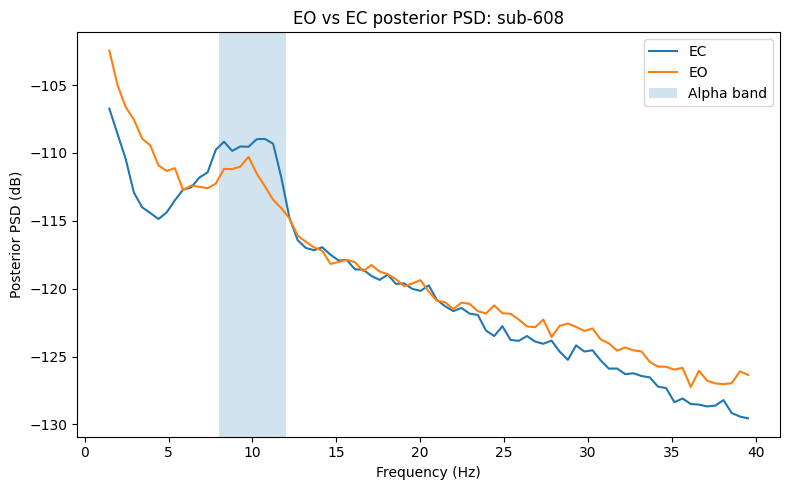

In [13]:
for participant in sample_subjects:
    participant_rows = sample_manifest[
        sample_manifest["participant_id"].eq(participant)
    ].copy()

    plt.figure(figsize=(8, 5))

    for _, row in participant_rows.iterrows():
        raw = load_raw_eeg(row, preload=True)
        raw_filt = preprocess_raw(raw)

        existing_posterior = [
            ch for ch in POSTERIOR_CHANNELS
            if ch in raw_filt.ch_names
        ]

        freqs, power = compute_mean_psd(
            raw_filt,
            picks=existing_posterior,
            fmin=1,
            fmax=40,
        )

        plt.plot(freqs, power_to_db(power), label=row["condition"])

    plt.axvspan(8, 12, alpha=0.2, label="Alpha band")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Posterior PSD (dB)")
    plt.title(f"EO vs EC posterior PSD: {participant}")
    plt.legend()
    plt.tight_layout()
    plt.show()
